<a href="https://colab.research.google.com/github/Tanman005/AI-ML-ASSIGNMENT-2/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Customer Churn Prediction using Logistic Regression

**Objective:** Predict whether a telecom customer is likely to churn based on demographic
information and service usage, using a Logistic Regression model.

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

> Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from the Kaggle link above and place it
> in the same folder as this notebook (or upload it to Colab) before running the cells below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## Task 1: Data Understanding (2 Marks)

1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify numerical features, categorical features, and the target variable.


In [2]:
# 1. Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# 2. Data types and basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# 3. Identify numerical vs categorical features and the target variable

# customerID is a unique identifier, not a predictive feature
target = "Churn"

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

# TotalCharges is stored as object due to blank strings for new customers -> treat as numerical
if "TotalCharges" in categorical_features:
    categorical_features.remove("TotalCharges")
    numerical_features.append("TotalCharges")

# customerID and the target itself are not predictive categorical features
categorical_features = [c for c in categorical_features if c not in ["customerID", target]]

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)
print("\nTarget variable:", target)


Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target variable: Churn


## Task 2: Data Preprocessing (2 Marks)

- Check for missing values.
- Handle missing values if any.
- Encode categorical variables.
- Split the dataset into 80% training and 20% testing.


In [5]:
# TotalCharges has blank strings for customers with tenure = 0; convert to numeric first
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check for missing values
print("Missing values per column:\n")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column:

TotalCharges    11
dtype: int64


In [6]:
# Handle missing values: fill the small number of missing TotalCharges
# (new customers with tenure = 0) with 0, since no charges have accrued yet
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing values after handling:", df.isnull().sum().sum())


Missing values after handling: 0


In [7]:
# Drop customerID (identifier, not predictive)
df_model = df.drop(columns=["customerID"])

# Encode the target variable
le_target = LabelEncoder()
df_model["Churn"] = le_target.fit_transform(df_model["Churn"])  # Yes -> 1, No -> 0

# Encode remaining categorical variables using one-hot encoding
categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_model.shape)
df_model.head()


Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [8]:
# Split features and target
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (5634, 30)
Testing set size: (1409, 30)


## Task 3: Model Development (3 Marks)

Build and train a Logistic Regression model on the selected features to predict `Churn`.


In [9]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print("Model training complete.")


Model training complete.


## Task 4: Model Evaluation (2 Marks)

Evaluate the model using Accuracy, Precision, Recall, and F1-Score, and generate a Confusion Matrix.


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


Accuracy  : 0.8070
Precision : 0.6584
Recall    : 0.5668
F1-Score  : 0.6092

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



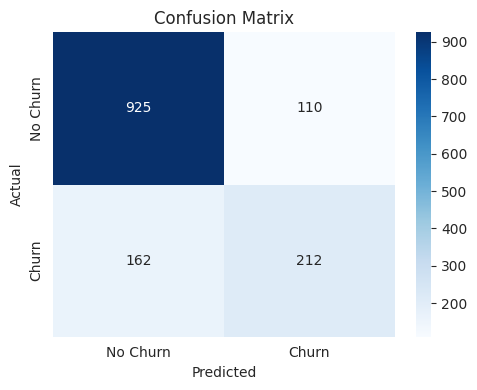

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### Observations

1. The model achieves reasonably high **accuracy**, but accuracy alone is misleading here
   because the dataset is imbalanced (fewer customers churn than stay).
2. **Recall** for the churn class is noticeably lower than precision, meaning the model misses
   a portion of customers who actually churn — an important gap for a business trying to act
   on churn risk.
3. Features such as `Contract`, `tenure`, and `InternetService` type tend to carry strong
   predictive weight (inspect `log_reg.coef_` against `X.columns` to confirm), consistent with
   the intuition that month-to-month, low-tenure customers churn more often.


In [12]:
# Optional: inspect top coefficients to see which features drive churn predictions
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

coef_df.head(10)


,feature,coefficient
1,tenure,-1.236528
2,MonthlyCharges,-0.920153
10,InternetService_Fiber optic,0.776154
25,Contract_Two year,-0.586859
3,TotalCharges,0.514285
24,Contract_One year,-0.285509
23,StreamingMovies_Yes,0.257227
21,StreamingTV_Yes,0.257144
9,MultipleLines_Yes,0.216167
26,PaperlessBilling_Yes,0.182034


## Task 5: Conclusion (1 Mark)

This Logistic Regression model provides a solid baseline for predicting customer churn using
demographic and service-usage attributes. The key findings show that contract type, tenure,
and internet/service add-ons are strong drivers of churn: customers on month-to-month
contracts with shorter tenure and fewer bundled services are considerably more likely to
leave, while long-tenure customers on annual or two-year contracts churn far less often.
Charges (both monthly and total) also play a role, suggesting price sensitivity contributes
to attrition. One notable limitation of Logistic Regression for this problem is that it
assumes a linear relationship between the log-odds of churn and the input features, so it
can struggle to capture more complex, non-linear interactions between variables (for example,
how tenure and contract type jointly affect churn risk) that a tree-based or ensemble model
might capture more effectively.
